In [1]:
import stim
import math
import pymatching
import sinter
import matplotlib.pyplot as plt
import os

In [2]:
def repetition_code(distance : int, Rounds : int, before_measurement_flip_prob : float = 0.0, 
                    before_round_data_depol : float = 0.0,
                    before_round_data_flip: float = 0.0,
                    before_round_data_Y: float = 0.0,
                    before_round_data_Z: float = 0.0) -> stim.Circuit:

    """Created manual Repetition Code implementation
    
        Args:
        -> Distance (Int): Gives Distance of the Code i.e. the number of data qubits
        -> Rounds (Int): Gives the number of Repeating rounds
        -> Noise (Float): Gives the probability of an initilization-Error at the beginning for the data qubits
    
        Returns:
        -> Stim.Circuit() with logical Z Operator
    """
    #-------Priliminary-Stup--------

    #Check Distance
    if distance%2 == 0:
        return(IndexError)

    #Defining ancilla positions:
    index_ancilla = []
    for i in range(1, distance*2, 2):
        if len(index_ancilla) != distance - 1:
            index_ancilla.append(i)

    #Defining Data positions:
    index_data = []
    for i in range(0, distance*2, 2):
        if len(index_data) != distance:
            index_data.append(i)

    #Defining CX-Pairs
    CX_Pairs : dict[list(int), str] = {}
    for i in index_ancilla:
        CX_Pairs[i-1, i] = "UPPER"
        CX_Pairs[i+1, i] = "LOWER"

    #Initlize Circuit
    round_circuit = stim.Circuit()
    final_circuit = stim.Circuit()

    #-------Initilization-Block---------
    
    #Qubit Coords
    for i,q in enumerate(index_ancilla + index_data):
        final_circuit.append("QUBIT_COORDS", [i], [i , 0])
    
    final_circuit.append("R", index_data)
    final_circuit.append("R", index_ancilla)

    final_circuit.append("TICK")

    #Adding Depolarize Noise after init
    if before_round_data_depol > 0.0:
        final_circuit.append("DEPOLARIZE1", index_data, before_round_data_depol)
        final_circuit.append("TICK")

    #Adding Flip Noise after init
    if before_round_data_flip > 0.0:
        final_circuit.append("X_ERROR", index_data, before_round_data_flip)
        final_circuit.append("TICK")

    #Adding Y Noise after init
    if before_round_data_Y > 0.0:
        final_circuit.append("Y_ERROR", index_data, before_round_data_Y)
        final_circuit.append("TICK")

    #Adding Z Noise after init
    if before_round_data_Z > 0.0:
        final_circuit.append("Z_ERROR", index_data, before_round_data_Z)
        final_circuit.append("TICK")

    #Adding Upper CX
    for index, qtype in CX_Pairs.items():
        if qtype == "UPPER":
            final_circuit.append("CX", index)

    final_circuit.append("TICK")

    #Adding Lower CX
    for index, qtype in CX_Pairs.items():
        if qtype == "LOWER":
            final_circuit.append("CX", index)

    final_circuit.append("TICK")

    #Adding before Measurement flip Noise
    if before_measurement_flip_prob > 0.0:
        final_circuit.append("X_ERROR", index_ancilla, before_measurement_flip_prob)

    #Adding Measurements/Detectors
    final_circuit.append("MR", index_ancilla)

    for i,q in enumerate(index_ancilla):
        current_tar = - len(index_ancilla) + i
        final_circuit.append("DETECTOR", [stim.target_rec(current_tar)], arg=(q,0,0))
    
    final_circuit.append("TICK")

    #-----------Repeat-Block-----------

    #Adding Depolarize Noise after init
    if before_round_data_depol > 0.0:
        round_circuit.append("DEPOLARIZE1", index_data, before_round_data_depol)
        round_circuit.append("TICK")

    #Adding Flip Noise after init
    if before_round_data_flip > 0.0:
        round_circuit.append("X_ERROR", index_data, before_round_data_flip)
        round_circuit.append("TICK")

    #Adding Y Noise after init
    if before_round_data_Y > 0.0:
        round_circuit.append("Y_ERROR", index_data, before_round_data_Y)
        round_circuit.append("TICK")

    #Adding Z Noise after init
    if before_round_data_Z > 0.0:
        round_circuit.append("Z_ERROR", index_data, before_round_data_Z)
        round_circuit.append("TICK")

    #Adding Upper CX
    for index, qtype in CX_Pairs.items():
        if qtype == "UPPER":
            round_circuit.append("CX", index)

    round_circuit.append("TICK")

    #Adding Lower CX
    for index, qtype in CX_Pairs.items():
        if qtype == "LOWER":
            round_circuit.append("CX", index)

    round_circuit.append("TICK")

    #Adding before Measurement flip Noise
    if before_measurement_flip_prob > 0.0:
        round_circuit.append("X_ERROR", index_ancilla, before_measurement_flip_prob)

    #Adding Measurements
    round_circuit.append("MR", index_ancilla)

    #Adding Detectors
    #-> Shifting Detectors to create Detector Graph Volume for temporal detection
    round_circuit.append("SHIFT_COORDS", arg = (0,0,1))

    for i,q in enumerate(index_ancilla):
        previous_tar = - 2 * len(index_ancilla) + i
        current_tar = - len(index_ancilla) + i
        round_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_tar)], arg=(q,0,0))

    round_circuit.append("TICK")

    #Construct final repetition Block
    final_circuit += round_circuit * (Rounds - 1)

    #-------Logical-Observables--------

    #Adding before Measurement flip Noise
    if before_measurement_flip_prob > 0.0:
        final_circuit.append("X_ERROR", index_data, before_measurement_flip_prob)

    
    final_circuit.append("M", index_data)

    #Implementing last Detector round
    for i, q in enumerate(index_data):
        if i != 0:
            prev_dec = - len(index_data) + i - len(index_ancilla) - 1
            upper_meas = - len(index_data) + i -1
            lower_meas = - len(index_data) + i
            final_circuit.append("DETECTOR", [stim.target_rec(prev_dec), stim.target_rec(upper_meas), stim.target_rec(lower_meas)], arg = (q, 0, 1))

    final_circuit.append("TICK")

    #Adding logical Observables 
    final_circuit.append("OBSERVABLE_INCLUDE", [stim.target_rec(- i -1) for i, q in enumerate(index_data)], 0)

    return final_circuit

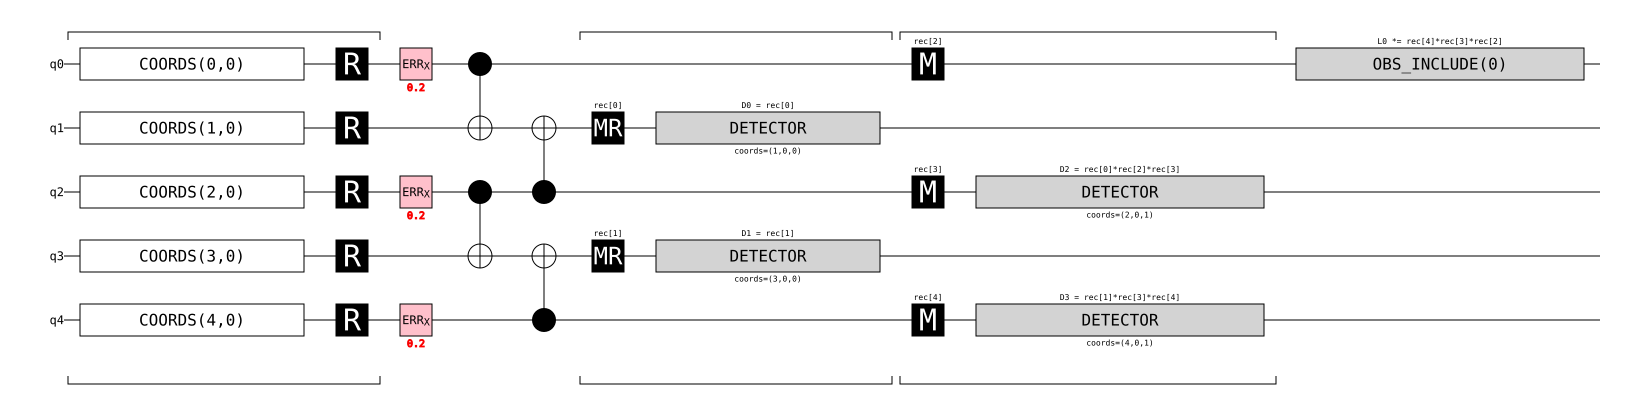

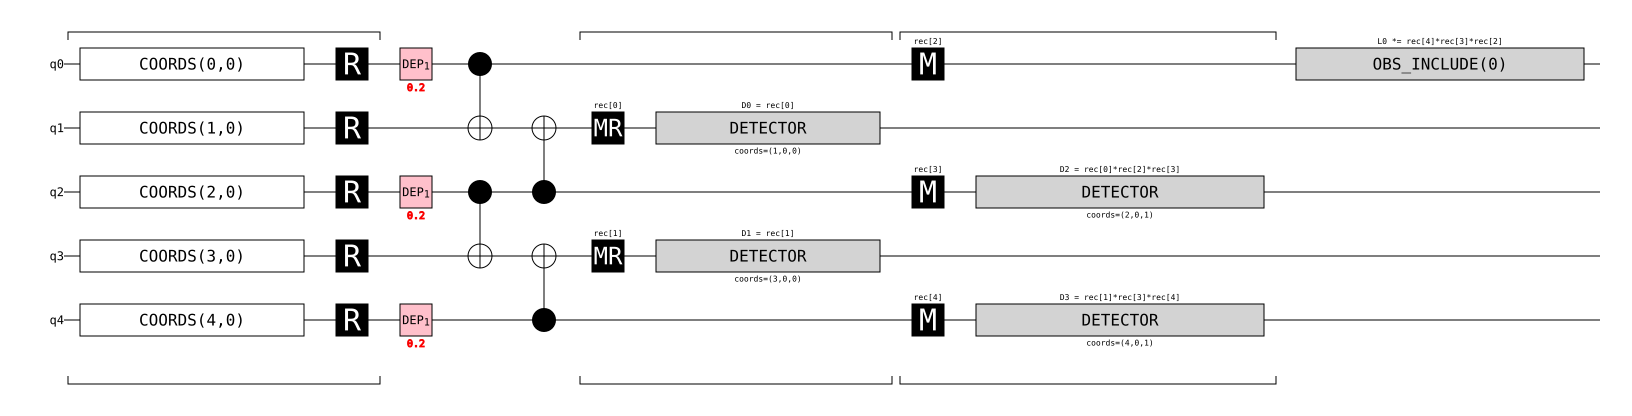

In [3]:
##################
# Current Ciruicts
##################

display(repetition_code(3,1, before_round_data_flip = 0.2).diagram("timeline-svg"))
display(repetition_code(3,1, before_round_data_depol = 0.2).diagram("timeline-svg"))

In [ ]:
#######################################################################
# Create Sinter Task Before Round Data Depolaz./X-Error/Y-Error/Z-Error
#######################################################################

tasks_depol = [sinter.Task(
    circuit= repetition_code(
        distance = d,
        Rounds = 1,
        before_round_data_depol = noise),
    json_metadata={'p': noise, 'distance': d, "rounds": d}
    ) 
    for noise in [0.005, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.65, 0.7] 
    for d in [3]
    ]

"""
We add The X error with prob. p * 2/3 to simulate the errors of the depol. noise which creates errors that can be detected i.e. bit flips
-> We simulate the 2/3p prob. of either x or y error in the depol. channel with an x error of prob 2/3 p
"""
tasks_x = [sinter.Task(
    circuit= repetition_code(
        distance = d,
        Rounds = 1,
        before_round_data_flip = noise * 2,
        ),
    json_metadata={'p': noise, 'distance': d, "rounds": d}
    )
    for noise in [0.005 * (1/3), 0.01 * (1/3), 0.02 * (1/3), 0.04 * (1/3), 0.06 * (1/3), 0.08 * (1/3), 0.1 * (1/3), 0.15 * (1/3), 0.2 * (1/3), 0.3 * (1/3), 0.4 * (1/3), 0.5 * (1/3), 0.55 * (1/3), 0.6 * (1/3), 0.65 * (1/3), 0.7 * (1/3)]
    for d in [3]
    ]

tasks_y = [sinter.Task(
    circuit= repetition_code(
        distance = d,
        Rounds = 1,
        before_round_data_Y = noise * 2,
        ),
    json_metadata={'p': noise, 'distance': d, "rounds": d}
    )
    for noise in [0.005 * (1/3), 0.01 * (1/3), 0.02 * (1/3), 0.04 * (1/3), 0.06 * (1/3), 0.08 * (1/3), 0.1 * (1/3), 0.15 * (1/3), 0.2 * (1/3), 0.3 * (1/3), 0.4 * (1/3), 0.5 * (1/3), 0.55 * (1/3), 0.6 * (1/3), 0.65 * (1/3), 0.7 * (1/3)]
    for d in [3]
    ]

tasks_z = [sinter.Task(
    circuit= repetition_code(
        distance = d,
        Rounds = 1,
        before_round_data_Z = noise * 2,
        ),
    json_metadata={'p': noise, 'distance': d, "rounds": d}
    )
    for noise in [0.005 * (1/3), 0.01 * (1/3), 0.02 * (1/3), 0.04 * (1/3), 0.06 * (1/3), 0.08 * (1/3), 0.1 * (1/3), 0.15 * (1/3), 0.2 * (1/3), 0.3 * (1/3), 0.4 * (1/3), 0.5 * (1/3), 0.55 * (1/3), 0.6 * (1/3), 0.65 * (1/3), 0.7 * (1/3)]
    for d in [3]
    ]

##############################################################
# Run Sinter Task Before Round Depolaz/X-Error/Y-Error/Z-Error
##############################################################

stats_depol : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=tasks_depol,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=1000,
    print_progress=True
)

stats_x : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=tasks_x,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=1000,
    print_progress=True
)

stats_y : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=tasks_y,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=1000,
    print_progress=True
)

stats_z : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=tasks_z,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=1000,
    print_progress=True
)

In [ ]:
####################################
# Filter out for distance 3 metadata
####################################

dist_3_error_x = []
dist_3_p_x = []
dist_3_error_y = []
dist_3_p_y = []
dist_3_error_z = []
dist_3_p_z = []

for stats in stats_x:
    if stats.json_metadata.get("distance") == 3:
        dist_3_error_x.append(stats.errors/stats.shots)
        #Return 3 times for comparison to depol. -> There x error p/3
        dist_3_p_x.append(stats.json_metadata.get("p") * 3)

for stats in stats_y:
    if stats.json_metadata.get("distance") == 3:
        dist_3_error_y.append(stats.errors/stats.shots)
        #Return 3 times for comparison to depol. -> There x error p/3
        dist_3_p_y.append(stats.json_metadata.get("p") * 3)

for stats in stats_z:
    if stats.json_metadata.get("distance") == 3:
        dist_3_error_z.append(stats.errors/stats.shots)
        #Return 3 times for comparison to depol. -> There x error p/3
        dist_3_p_z.append(stats.json_metadata.get("p") * 3)

##############
# Sorting Data
##############

sorted_pairs_x = sorted(zip(dist_3_p_x, dist_3_error_x))
sorted_pairs_y = sorted(zip(dist_3_p_y, dist_3_error_y))
sorted_pairs_z = sorted(zip(dist_3_p_z, dist_3_error_z))
d_3_e_sorted_x, d_3_p_sorted_x = zip(*sorted_pairs_x)
d_3_e_sorted_y, d_3_p_sorted_y = zip(*sorted_pairs_y)
d_3_e_sorted_z, d_3_p_sorted_z = zip(*sorted_pairs_z)

In [ ]:
################
# Plotting Graph
################

fig, ax = plt.subplots(1,1)
ax.plot(d_3_e_sorted_x, d_3_p_sorted_x, label = "Manual X-Flips", marker = ">", linestyle = ":")
ax.plot(d_3_e_sorted_y, d_3_p_sorted_y, label = "Manual Y-Flips", marker = "s", linestyle = "-")
ax.plot(d_3_e_sorted_z, d_3_p_sorted_z, label = "Manual Z-Flips", marker = "s", linestyle = "-")
sinter.plot_error_rate(
    ax=ax,
    stats=stats_depol,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'],
)
#ax.loglog()
ax.set_xlim(5e-3, 0.8)
ax.set_title("Repetition Code Error Rates (Before Round Data Depol vs X/Y-Flip: One-Shot)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [ ]:
############################
# This is the current Ciruit
############################

repetition_code(3,1, before_round_data_flip = 0.2).diagram("timeline-svg")

In [ ]:
#########################################
# Create Sinter Task Before Round X-Error
#########################################

"""
We now look at the Noise Model of only X-Errors but with a higher probability than 3/4 of an error occuring 
-> Limit of the Depol. Channel (As more would invert the bloch sphere in itself)
"""

tasks_x_full = [sinter.Task(
    circuit= repetition_code(
        distance = d,
        Rounds = 1,
        before_round_data_flip = noise,
        ),
    json_metadata={'p': noise, 'distance': d, "rounds": d}
    )
    for noise in [0.005 , 0.01 , 0.02 , 0.04 , 0.06 , 0.08 , 0.1 , 0.15 , 0.2 , 0.3 , 0.4 , 0.5 , 0.55 , 0.6 , 0.65 , 0.7, 0.8, 0.9, 0.99]
    for d in [3]
    ]

######################################
# Run Sinter Task Before Round x-Error
######################################

stats_x_full : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=tasks_x_full,
    decoders=["pymatching"],
    max_shots=100_000,
    max_errors=1000,
    print_progress=True
)

In [ ]:
#########################################################
# Plotting Logical Error-Rate against physical err. prob.
#########################################################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_x_full,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'],
)
ax.set_xlim(5e-2, 0.99)
ax.set_title("Repetition Code Error Rates (Only Data X Flips, One Shot))")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

Note that the edge weight w[i] = log((1 − p[i])/p[i]) is negative when p[i] > 0.5. Our sparse
blossom algorithm instead assumes that edge weights are non-negative. Fortunately, it is straightforward to decode a syndrome s for a detector graph G containing negative edge weights by using
efficient pre- and post-processing to instead decode a modified syndrome s
′ using a set of adjusted
edge weights v containing only non-negative edge weights. This procedure is used to handle negative edge weights in PyMatching and is explained in Appendix C. However, from now on we
will assume, without loss of generality, that we have a graph containing only non-negative edge
weights.

-> Sparse-Blossom Paper

https://quantumcomputing.stackexchange.com/questions/44094/why-does-the-logical-error-rate-decrease-with-higher-physical-error-with-pymatch/44096#44096